In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold
import pennylane as qml

In [2]:
DATA_DIR   = r"D:\vit_data"
BATCH_SIZE = 8
EPOCHS     = 10
LR         = 3e-4
IMG_SIZE   = 224
N_FOLDS    = 5
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [4]:
from PIL import Image

def remove_corrupt_images(root_dir):
    for root, _, files in os.walk(root_dir):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupt:", path)
                os.remove(path)

remove_corrupt_images(DATA_DIR)

# Use a base dataset WITHOUT transforms (we'll apply per-fold)
base_dataset = datasets.ImageFolder(DATA_DIR)

labels_all = [s[1] for s in base_dataset.samples]
classes    = base_dataset.classes
counts     = {c: labels_all.count(i) for i, c in enumerate(classes)}
print("Classes:", classes)
print("Class counts:", counts)

# ── Compute class weights to fight imbalance ──────────────────────
total = len(labels_all)
class_weights = torch.tensor(
    [total / (len(classes) * counts[c]) for c in classes],
    dtype=torch.float
).to(DEVICE)
print("Class weights:", class_weights)

Classes: ['train', 'val']
Class counts: {'train': 9089, 'val': 2201}
Class weights: tensor([0.6211, 2.5647])


In [5]:
n_qubits    = 4
n_qlayers   = 2   # ← more expressive than 1 layer
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Normalize inputs to [-π, π] using tanh
    inputs = np.pi * torch.tanh(inputs)

    # Encode
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Multi-layer entanglement
    for layer in range(n_qlayers):
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])  # ring entanglement
        for i in range(n_qubits):
            qml.RX(weights[layer, i], wires=i)
            qml.RZ(weights[layer, i], wires=i)  # extra rotation axis

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [6]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=192):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) ** 2

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return F.layer_norm(x, (x.size(-1),))


class MSA(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.heads    = heads
        self.head_dim = dim // heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(0.1)
        self.proj = nn.Sequential(nn.Linear(dim, dim), nn.Dropout(0.1))

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        out  = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class FeedForward(nn.Module):
    def __init__(self, dim=192):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(dim * 2, dim), nn.Dropout(0.1)
        )

    def forward(self, x):
        return self.fc(x)


class Block(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MSA(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.ff    = FeedForward(dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

In [7]:
class QViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch = PatchEmbed()
        n = self.patch.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, 192))
        self.pos_emb   = nn.Parameter(torch.zeros(1, n + 1, 192))

        self.blocks = nn.ModuleList([Block() for _ in range(6)])
        self.norm   = nn.LayerNorm(192)

        self.proj     = nn.Linear(192, n_qubits)
        # Shape: (n_qlayers, n_qubits) to match deeper circuit
        self.q_weights = nn.Parameter(torch.randn(n_qlayers, n_qubits) * 0.1)
        self.head      = nn.Linear(n_qubits, 2)

        nn.init.trunc_normal_(self.pos_emb,   std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)

        x   = self.patch(x)
        cls = self.cls_token.expand(B, -1, -1)   # ← REMOVED * 0.1
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_emb[:, :x.size(1)]

        for blk in self.blocks:
            x = blk(x)

        x         = self.norm(x)
        cls_token = x[:, 0]
        x_q       = self.proj(cls_token)

        q_out = []
        for i in range(B):
            q = quantum_circuit(x_q[i], self.q_weights)
            q_out.append(torch.stack(q).float())

        q_out = torch.stack(q_out).to(x.device)
        return self.head(q_out)

print("QViT defined ✓")

QViT defined ✓


In [8]:
# ── Need full dataset with labels for stratification ──────────────
all_labels_arr = np.array([s[1] for s in base_dataset.samples])

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(
        np.zeros(len(all_labels_arr)), all_labels_arr)):

    print(f"\n{'='*40}")
    print(f"  FOLD {fold+1} / {N_FOLDS}")
    print(f"{'='*40}")

    # Apply correct transforms per split
    train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
    val_dataset   = datasets.ImageFolder(DATA_DIR, transform=val_transform)

    train_loader = DataLoader(Subset(train_dataset, train_idx),
                              batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(Subset(val_dataset,   val_idx),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = QViT().to(DEVICE)
    # ── Weighted loss fixes class imbalance ───────────────────────
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_loss = float('inf')
    patience, trigger = 4, 0

    for epoch in range(EPOCHS):
        # ── Train ────────────────────────────────────────────────
        model.train()
        train_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stability
            optimizer.step()

            train_loss += loss.item()
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

        scheduler.step()
        train_acc  = correct / total
        train_loss /= len(train_loader)

        # ── Validate ─────────────────────────────────────────────
        model.eval()
        val_loss   = 0
        all_preds, all_probs_fold, all_true = [], [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs  = model(imgs)
                val_loss += criterion(outputs, labels).item()

                probs = torch.softmax(outputs, dim=1)[:, 1]
                preds = outputs.argmax(1)

                all_preds.extend(preds.cpu().numpy())
                all_probs_fold.extend(probs.cpu().numpy())
                all_true.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc   = accuracy_score(all_true, all_preds)
        val_f1    = f1_score(all_true, all_preds, zero_division=0)

        print(f"Epoch {epoch+1:2d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger       = 0
            torch.save(model.state_dict(), f"qvit_best_fold{fold+1}.pth")
        else:
            trigger += 1
            if trigger >= patience:
                print("  ↳ Early stopping triggered")
                break

    # ── Load best checkpoint for final fold metrics ───────────────
    model.load_state_dict(torch.load(f"qvit_best_fold{fold+1}.pth",
                                      map_location=DEVICE))
    model.eval()
    all_preds, all_probs_fold, all_true = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs  = imgs.to(DEVICE)
            out   = model(imgs)
            probs = torch.softmax(out, dim=1)[:, 1]
            preds = out.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_probs_fold.extend(probs.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_true, all_preds)
    f1   = f1_score(all_true, all_preds, zero_division=0)
    prec = precision_score(all_true, all_preds, zero_division=0)
    rec  = recall_score(all_true, all_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_true, all_probs_fold)
    except:
        auc = float('nan')

    tn, fp, fn, tp = confusion_matrix(all_true, all_preds).ravel()
    spec = tn / (tn + fp + 1e-8)

    print(f"\n  ── Fold {fold+1} Best Results ──")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1:          {f1:.4f}")
    print(f"  Precision:   {prec:.4f}")
    print(f"  Recall:      {rec:.4f}")
    print(f"  Specificity: {spec:.4f}")
    print(f"  AUC-ROC:     {auc:.4f}")

    fold_results.append({
        "fold": fold + 1,
        "acc": acc, "f1": f1, "precision": prec,
        "recall": rec, "specificity": spec, "auc": auc
    })


  FOLD 1 / 5
Epoch  1 | Train Loss: 0.7015 | Train Acc: 0.5549 | Val Loss: 0.6516 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  2 | Train Loss: 0.6867 | Train Acc: 0.8050 | Val Loss: 0.6475 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  3 | Train Loss: 0.6859 | Train Acc: 0.8050 | Val Loss: 0.6521 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  4 | Train Loss: 0.6866 | Train Acc: 0.8050 | Val Loss: 0.6460 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  5 | Train Loss: 0.6864 | Train Acc: 0.8050 | Val Loss: 0.6498 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  6 | Train Loss: 0.6872 | Train Acc: 0.8050 | Val Loss: 0.6504 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  7 | Train Loss: 0.6868 | Train Acc: 0.8050 | Val Loss: 0.6497 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  8 | Train Loss: 0.6866 | Train Acc: 0.8050 | Val Loss: 0.6473 | Val Acc: 0.8051 | Val F1: 0.0000
  ↳ Early stopping triggered


C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\3853186243.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"qvit_best_fold{fold+1}.pt


  ── Fold 1 Best Results ──
  Accuracy:    0.8051
  F1:          0.0000
  Precision:   0.0000
  Recall:      0.0000
  Specificity: 1.0000
  AUC-ROC:     0.5133

  FOLD 2 / 5
Epoch  1 | Train Loss: 0.7031 | Train Acc: 0.8050 | Val Loss: 0.6357 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  2 | Train Loss: 0.6850 | Train Acc: 0.8050 | Val Loss: 0.6437 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  3 | Train Loss: 0.6867 | Train Acc: 0.8050 | Val Loss: 0.6500 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  4 | Train Loss: 0.6866 | Train Acc: 0.8050 | Val Loss: 0.6471 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  5 | Train Loss: 0.6869 | Train Acc: 0.8050 | Val Loss: 0.6483 | Val Acc: 0.8051 | Val F1: 0.0000
  ↳ Early stopping triggered


C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\3853186243.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"qvit_best_fold{fold+1}.pt


  ── Fold 2 Best Results ──
  Accuracy:    0.8051
  F1:          0.0000
  Precision:   0.0000
  Recall:      0.0000
  Specificity: 1.0000
  AUC-ROC:     0.4810

  FOLD 3 / 5
Epoch  1 | Train Loss: 0.7094 | Train Acc: 0.8035 | Val Loss: 0.6394 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  2 | Train Loss: 0.6919 | Train Acc: 0.8050 | Val Loss: 0.6217 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  3 | Train Loss: 0.6881 | Train Acc: 0.8050 | Val Loss: 0.6394 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  4 | Train Loss: 0.6870 | Train Acc: 0.8050 | Val Loss: 0.6490 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  5 | Train Loss: 0.6872 | Train Acc: 0.8050 | Val Loss: 0.6221 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  6 | Train Loss: 0.6878 | Train Acc: 0.8050 | Val Loss: 0.6673 | Val Acc: 0.8051 | Val F1: 0.0000
  ↳ Early stopping triggered


...


  ── Fold 3 Best Results ──
  Accuracy:    0.8051
  F1:          0.0000
  Precision:   0.0000
  Recall:      0.0000
  Specificity: 1.0000
  AUC-ROC:     0.5134

  FOLD 4 / 5
Epoch  1 | Train Loss: 0.6938 | Train Acc: 0.6250 | Val Loss: 0.6565 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  2 | Train Loss: 0.6867 | Train Acc: 0.8050 | Val Loss: 0.6548 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  3 | Train Loss: 0.6866 | Train Acc: 0.8050 | Val Loss: 0.6467 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  4 | Train Loss: 0.6862 | Train Acc: 0.8050 | Val Loss: 0.6384 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  5 | Train Loss: 0.6862 | Train Acc: 0.8050 | Val Loss: 0.6457 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  6 | Train Loss: 0.6874 | Train Acc: 0.8050 | Val Loss: 0.6464 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  7 | Train Loss: 0.6853 | Train Acc: 0.8050 | Val Loss: 0.6464 | Val Acc: 0.8051 | Val F1: 0.0000
Epoch  8 | Train Loss: 0.6866 | Train Acc: 0.8050 | Val Loss: 0.6481 | Val Acc: 0.8051 | Val F1: 

C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\3853186243.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"qvit_best_fold{fold+1}.pt


  ── Fold 4 Best Results ──
  Accuracy:    0.8051
  F1:          0.0000
  Precision:   0.0000
  Recall:      0.0000
  Specificity: 1.0000
  AUC-ROC:     0.4875

  FOLD 5 / 5
Epoch  1 | Train Loss: 0.6977 | Train Acc: 0.6531 | Val Loss: 0.6528 | Val Acc: 0.8047 | Val F1: 0.0000
Epoch  2 | Train Loss: 0.6863 | Train Acc: 0.8051 | Val Loss: 0.6408 | Val Acc: 0.8047 | Val F1: 0.0000
Epoch  3 | Train Loss: 0.6872 | Train Acc: 0.8051 | Val Loss: 0.6493 | Val Acc: 0.8047 | Val F1: 0.0000
Epoch  4 | Train Loss: 0.6871 | Train Acc: 0.8051 | Val Loss: 0.6499 | Val Acc: 0.8047 | Val F1: 0.0000
Epoch  5 | Train Loss: 0.6869 | Train Acc: 0.8051 | Val Loss: 0.6421 | Val Acc: 0.8047 | Val F1: 0.0000
Epoch  6 | Train Loss: 0.6858 | Train Acc: 0.8051 | Val Loss: 0.6480 | Val Acc: 0.8047 | Val F1: 0.0000
  ↳ Early stopping triggered


C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\3853186243.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"qvit_best_fold{fold+1}.pt


  ── Fold 5 Best Results ──
  Accuracy:    0.8047
  F1:          0.0000
  Precision:   0.0000
  Recall:      0.0000
  Specificity: 1.0000
  AUC-ROC:     0.5131


In [9]:
import pandas as pd

df = pd.DataFrame(fold_results).set_index("fold")
print("\n========== CROSS-VALIDATION SUMMARY ==========")
print(df.to_string())
print("\n── Mean ──")
print(df.mean().to_string())
print("\n── Std ──")
print(df.std().to_string())


========== CROSS-VALIDATION SUMMARY ==========
           acc   f1  precision  recall  specificity       auc
fold                                                         
1     0.805137  0.0        0.0     0.0          1.0  0.513327
2     0.805137  0.0        0.0     0.0          1.0  0.481016
3     0.805137  0.0        0.0     0.0          1.0  0.513379
4     0.805137  0.0        0.0     0.0          1.0  0.487541
5     0.804694  0.0        0.0     0.0          1.0  0.513098

── Mean ──
acc            0.805049
f1             0.000000
precision      0.000000
recall         0.000000
specificity    1.000000
auc            0.501672

── Std ──
acc            1.980574e-04
f1             0.000000e+00
precision      0.000000e+00
recall         0.000000e+00
specificity    1.341488e-15
auc            1.604501e-02


In [10]:
# Pick the fold with highest AUC
best_fold = df["auc"].idxmax()
print(f"Best fold by AUC: Fold {best_fold}")

import shutil
shutil.copy(f"qvit_best_fold{best_fold}.pth", "ecg_qvit_final.pth")
print("Saved ecg_qvit_final.pth")

Best fold by AUC: Fold 3
Saved ecg_qvit_final.pth



===== FETAL CARDIAC ANALYSIS =====
Prediction: normal
Confidence: 54.68 %
Fetal Heart Rate: 101.43 bpm


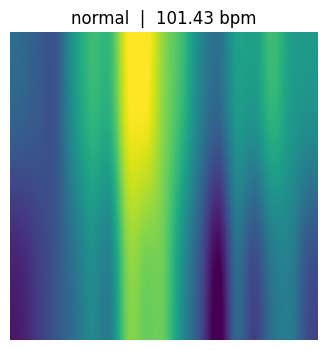

In [15]:
import os
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import wfdb
import neurokit2 as nk
import numpy as np
from scipy.signal import butter, filtfilt

# ---------------- IMAGE PATH ----------------
img_path = r"D:\vit_data\val\arrhythmia\ARR_03_809.png"

# ---------------- HEART RATE FUNCTION ----------------
def fetal_bandpass(ecg, fs):
    low = 5/(fs/2)
    high = 45/(fs/2)
    b, a = butter(3, [low, high], btype='bandpass')
    return filtfilt(b, a, ecg)

def compute_fetal_hr(image_path):

    filename = os.path.basename(image_path)
    parts = filename.split("_")
    record_name = parts[0] + "_" + parts[1]

    # choose folder
    if record_name.startswith("NR"):
        record_path = os.path.join("ecg_data", "normal", record_name)
    else:
        record_path = os.path.join("ecg_data", "arrhythmia", record_name)

    record = wfdb.rdrecord(record_path)
    ecg = record.p_signal[:,0]
    fs = record.fs

    cleaned = nk.ecg_clean(ecg, sampling_rate=fs)
    filtered = fetal_bandpass(cleaned, fs)
    filtered = filtered * 5

    _, info = nk.ecg_peaks(filtered, sampling_rate=fs, method="neurokit")
    peaks = info["ECG_R_Peaks"]

    rr_intervals = np.diff(peaks) / fs
    fetal_rr = rr_intervals[(rr_intervals > 0.25) & (rr_intervals < 0.65)]

    if len(fetal_rr) == 0:
        return "Not detected"

    heart_rate = 60 / np.mean(fetal_rr)
    return round(heart_rate,2)

# ---------------- CLASSIFICATION ----------------
model.eval()

img = Image.open(img_path)
x = train_transform(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = model(x)

    # FIX dimension bug
    if out.dim() == 1:
        out = out.unsqueeze(0)

    probs = torch.softmax(out, dim=1)
    confidence, pred = torch.max(probs, dim=1)

pred = pred.item()
confidence = confidence.item()

classes = ["normal","arrthymia"]

# ---------------- HEART RATE ----------------
heart_rate = compute_fetal_hr(img_path)

# ---------------- OUTPUT ----------------
print("\n===== FETAL CARDIAC ANALYSIS =====")
print("Prediction:", classes[pred])
print("Confidence:", round(confidence*100,2), "%")
print("Fetal Heart Rate:", heart_rate, "bpm")

# ---------------- DISPLAY IMAGE ----------------
plt.figure(figsize=(5,4))
plt.imshow(img, cmap="viridis")
plt.title(f"{classes[pred]}  |  {heart_rate} bpm")
plt.axis("off")
plt.show()


===== FETAL CARDIAC ANALYSIS =====
Prediction: normal
Confidence: 54.68 %
Fetal Heart Rate: 103.97 bpm


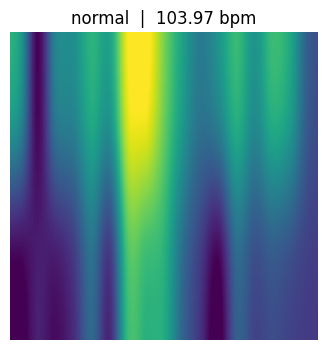

In [14]:
import os
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import wfdb
import neurokit2 as nk
import numpy as np
from scipy.signal import butter, filtfilt

# ---------------- IMAGE PATH ----------------
img_path = r"D:\vit_data\val\normal\NR_01_125.png"

# ---------------- HEART RATE FUNCTION ----------------
def fetal_bandpass(ecg, fs):
    low = 5/(fs/2)
    high = 45/(fs/2)
    b, a = butter(3, [low, high], btype='bandpass')
    return filtfilt(b, a, ecg)

def compute_fetal_hr(image_path):

    filename = os.path.basename(image_path)
    parts = filename.split("_")
    record_name = parts[0] + "_" + parts[1]

    # choose folder
    if record_name.startswith("NR"):
        record_path = os.path.join("ecg_data", "normal", record_name)
    else:
        record_path = os.path.join("ecg_data", "arrhythmia", record_name)

    record = wfdb.rdrecord(record_path)
    ecg = record.p_signal[:,0]
    fs = record.fs

    cleaned = nk.ecg_clean(ecg, sampling_rate=fs)
    filtered = fetal_bandpass(cleaned, fs)
    filtered = filtered * 5

    _, info = nk.ecg_peaks(filtered, sampling_rate=fs, method="neurokit")
    peaks = info["ECG_R_Peaks"]

    rr_intervals = np.diff(peaks) / fs
    fetal_rr = rr_intervals[(rr_intervals > 0.25) & (rr_intervals < 0.65)]

    if len(fetal_rr) == 0:
        return "Not detected"

    heart_rate = 60 / np.mean(fetal_rr)
    return round(heart_rate,2)

# ---------------- CLASSIFICATION ----------------
model.eval()

img = Image.open(img_path)
x = train_transform(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = model(x)

    # FIX dimension bug
    if out.dim() == 1:
        out = out.unsqueeze(0)

    probs = torch.softmax(out, dim=1)
    confidence, pred = torch.max(probs, dim=1)

pred = pred.item()
confidence = confidence.item()

classes = ["normal","arrhythmia"]

# ---------------- HEART RATE ----------------
heart_rate = compute_fetal_hr(img_path)

# ---------------- OUTPUT ----------------
print("\n===== FETAL CARDIAC ANALYSIS =====")
print("Prediction:", classes[pred])
print("Confidence:", round(confidence*100,2), "%")
print("Fetal Heart Rate:", heart_rate, "bpm")

# ---------------- DISPLAY IMAGE ----------------
plt.figure(figsize=(5,4))
plt.imshow(img, cmap="viridis")
plt.title(f"{classes[pred]}  |  {heart_rate} bpm")
plt.axis("off")
plt.show()

In [16]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold
from PIL import Image
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [17]:
DATA_DIR     = r"D:\vit_data"
COMBINED_DIR = r"D:\vit_data\all_data"
BATCH_SIZE   = 8
EPOCHS       = 10
LR           = 3e-4
N_FOLDS      = 5
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [18]:
for split in ["train", "val"]:
    for cls in ["normal", "arrhythmia"]:
        src = os.path.join(DATA_DIR, split, cls)
        dst = os.path.join(COMBINED_DIR, cls)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            src_file = os.path.join(src, f)
            dst_file = os.path.join(dst, f)
            if not os.path.exists(dst_file):
                shutil.copy(src_file, dst_file)

print("Done combining!")

Done combining!


In [19]:
def remove_corrupt_images(root_dir):
    for root, _, files in os.walk(root_dir):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupt:", path)
                os.remove(path)

remove_corrupt_images(COMBINED_DIR)

base_dataset = datasets.ImageFolder(COMBINED_DIR)
labels_all   = np.array([s[1] for s in base_dataset.samples])
classes      = base_dataset.classes   # ['arrhythmia', 'normal']

counts = np.bincount(labels_all)
print("Classes:", classes)
print("Class counts:", {c: int(counts[i]) for i, c in enumerate(classes)})

# Inverse frequency weighting
class_weights = torch.tensor(
    len(labels_all) / (len(classes) * counts),
    dtype=torch.float
).to(DEVICE)
print("Class weights:", class_weights)

Classes: ['arrhythmia', 'normal']
Class counts: {'arrhythmia': 6006, 'normal': 4991}
Class weights: tensor([0.9155, 1.1017])


In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [21]:
n_qubits  = 4
n_qlayers = 3
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Normalize inputs to valid rotation range
    inputs = np.pi * torch.tanh(inputs)

    # Data re-uploading: re-encode at every layer to avoid barren plateau
    for layer in range(n_qlayers):
        for i in range(n_qubits):
            qml.RY(inputs[i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])   # ring entanglement
        for i in range(n_qubits):
            qml.Rot(weights[layer, i, 0],
                    weights[layer, i, 1],
                    weights[layer, i, 2], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

print("Quantum circuit defined ✓")

Quantum circuit defined ✓


In [22]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=192):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) ** 2

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return F.layer_norm(x, (x.size(-1),))


class MSA(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.heads     = heads
        self.head_dim  = dim // heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(0.1)
        self.proj      = nn.Sequential(nn.Linear(dim, dim), nn.Dropout(0.1))

    def forward(self, x):
        B, N, C = x.shape
        qkv     = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)
        attn    = (q @ k.transpose(-2, -1)) * self.scale
        attn    = attn.softmax(dim=-1)
        attn    = self.attn_drop(attn)
        out     = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class FeedForward(nn.Module):
    def __init__(self, dim=192):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(dim * 2, dim), nn.Dropout(0.1)
        )

    def forward(self, x):
        return self.fc(x)


class Block(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MSA(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.ff    = FeedForward(dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

print("ViT blocks defined ✓")

ViT blocks defined ✓


In [25]:
class QViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch     = PatchEmbed()
        n              = self.patch.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 192))
        self.pos_emb   = nn.Parameter(torch.zeros(1, n + 1, 192))
        self.blocks    = nn.ModuleList([Block() for _ in range(6)])
        self.norm      = nn.LayerNorm(192)

        # Quantum parts
        self.proj = nn.Sequential(
            nn.Linear(192, n_qubits),
            nn.Tanh()
        )
        self.q_weights = nn.Parameter(
            torch.randn(n_qlayers, n_qubits, 3) * 0.01
        )
        self.head = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 2)
        )

        nn.init.trunc_normal_(self.pos_emb,   std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def load_vit_backbone(self, vit_path, device):
        """Load only the ViT backbone weights, ignore head"""
        vit_state   = torch.load(vit_path, map_location=device)

        # Only copy weights that exist in QViT backbone (skip vit's head)
        qvit_state  = self.state_dict()
        loaded, skipped = [], []

        for k, v in vit_state.items():
            if k in qvit_state and qvit_state[k].shape == v.shape:
                qvit_state[k] = v
                loaded.append(k)
            else:
                skipped.append(k)

        self.load_state_dict(qvit_state)
        print(f"  Loaded  {len(loaded)} layers from ViT")
        print(f"  Skipped {len(skipped)} layers: {skipped}")

    def freeze_backbone(self):
        """Freeze everything except quantum proj + weights + head"""
        for name, param in self.named_parameters():
            if any(x in name for x in ["proj", "q_weights", "head"]):
                param.requires_grad = True
            else:
                param.requires_grad = False
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        frozen    = sum(p.numel() for p in self.parameters() if not p.requires_grad)
        print(f"  Trainable params : {trainable:,}")
        print(f"  Frozen params    : {frozen:,}")

    def unfreeze_all(self):
        for param in self.parameters():
            param.requires_grad = True
        print("  All params unfrozen ✓")

    def forward(self, x):
        B   = x.size(0)
        x   = self.patch(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_emb[:, :x.size(1)]

        for blk in self.blocks:
            x = blk(x)

        x     = self.norm(x)
        x_q   = self.proj(x[:, 0])

        q_out = []
        for i in range(B):
            q = quantum_circuit(x_q[i], self.q_weights)
            q_out.append(torch.stack(q).float())

        q_out = torch.stack(q_out).to(x.device)
        return self.head(q_out)

print("QViT defined ✓")

QViT defined ✓


In [29]:
VIT_PATH     = "ecg_vit_model.pth"   # ← your trained ViT path
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(labels_all)), labels_all)):

    print(f"\n{'='*50}")
    print(f"  FOLD {fold+1} / {N_FOLDS}")
    print(f"{'='*50}")
    print(f"  Train: {np.bincount(labels_all[train_idx])}  "
          f"Val: {np.bincount(labels_all[val_idx])}")

    train_ds = datasets.ImageFolder(COMBINED_DIR, transform=train_transform)
    val_ds   = datasets.ImageFolder(COMBINED_DIR, transform=val_transform)

    train_loader = DataLoader(Subset(train_ds, train_idx),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader   = DataLoader(Subset(val_ds, val_idx),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # ── Load pretrained ViT backbone into QViT ─────────────────
    model = QViT().to(DEVICE)
    model.load_vit_backbone(VIT_PATH, DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # ===========================================================
    # PHASE 1 — Quantum + head only (backbone frozen)
    # 8 epochs, higher LR since only small number of params
    # ===========================================================
    print("\n  [Phase 1] Training quantum layer + head only...")
    model.freeze_backbone()

    optim_q   = torch.optim.AdamW(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    lr=5e-4, weight_decay=1e-4)
    sched_q   = torch.optim.lr_scheduler.CosineAnnealingLR(optim_q, T_max=8)

    for epoch in range(8):
        model.train()
        correct, total, loss_sum = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optim_q.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim_q.step()

            loss_sum += loss.item()
            correct  += out.argmax(1).eq(labels).sum().item()
            total    += labels.size(0)

        sched_q.step()

        # Val check
        model.eval()
        preds_ep, probs_ep, true_ep = [], [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(DEVICE)
                out  = model(imgs)
                probs = torch.softmax(out, dim=1)[:, 1]
                preds_ep.extend(out.argmax(1).cpu().numpy())
                probs_ep.extend(probs.cpu().numpy())
                true_ep.extend(labels.numpy())

        f1_ep  = f1_score(true_ep, preds_ep, zero_division=0)
        rec_ep = recall_score(true_ep, preds_ep, zero_division=0)
        print(f"    Q-Ep {epoch+1} | Loss {loss_sum/len(train_loader):.4f} "
              f"| TrainAcc {correct/total:.4f} "
              f"| ValF1 {f1_ep:.4f} | ValRecall {rec_ep:.4f}")

    # ===========================================================
    # PHASE 2 — Fine-tune full model at low LR
    # ===========================================================
    print("\n  [Phase 2] Full model fine-tuning...")
    model.unfreeze_all()

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5,  # low LR to not destroy ViT weights
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS)

    best_f1   = 0.0
    patience  = 5
    trigger   = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

        scheduler.step()

        model.eval()
        val_loss = 0
        preds_ep, probs_ep, true_ep = [], [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out       = model(imgs)
                val_loss += criterion(out, labels).item()
                probs     = torch.softmax(out, dim=1)[:, 1]
                preds     = out.argmax(1)
                preds_ep.extend(preds.cpu().numpy())
                probs_ep.extend(probs.cpu().numpy())
                true_ep.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_f1    = f1_score(true_ep, preds_ep, zero_division=0)
        val_acc   = accuracy_score(true_ep, preds_ep)
        val_rec   = recall_score(true_ep, preds_ep, zero_division=0)

        print(f"  Ep {epoch+1:2d} | Loss {val_loss:.4f} | "
              f"Acc {val_acc:.3f} | F1 {val_f1:.3f} | "
              f"Recall {val_rec:.3f} | TrainAcc {correct/total:.3f}")

        if val_f1 >= best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"qvit_best_fold{fold+1}.pth")
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print("  ↳ Early stopping triggered")
                break

    # ── Final fold metrics ──────────────────────────────────────
    model.load_state_dict(
        torch.load(f"qvit_best_fold{fold+1}.pth", map_location=DEVICE))
    model.eval()
    preds_f, probs_f, true_f = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs  = imgs.to(DEVICE)
            out   = model(imgs)
            probs = torch.softmax(out, dim=1)[:, 1]
            preds = out.argmax(1)
            preds_f.extend(preds.cpu().numpy())
            probs_f.extend(probs.cpu().numpy())
            true_f.extend(labels.cpu().numpy())

    acc  = accuracy_score(true_f, preds_f)
    f1   = f1_score(true_f, preds_f, zero_division=0)
    prec = precision_score(true_f, preds_f, zero_division=0)
    rec  = recall_score(true_f, preds_f, zero_division=0)
    try:    auc = roc_auc_score(true_f, probs_f)
    except: auc = float('nan')

    cm             = confusion_matrix(true_f, preds_f)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, cm[0,0])
    spec           = tn / (tn + fp + 1e-8)

    print(f"\n  ── Fold {fold+1} Results ──")
    print(f"  Acc={acc:.4f} | F1={f1:.4f} | Prec={prec:.4f}")
    print(f"  Recall={rec:.4f} | Spec={spec:.4f} | AUC={auc:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    fold_results.append(dict(fold=fold+1, acc=acc, f1=f1,
                             precision=prec, recall=rec,
                             specificity=spec, auc=auc))

## What changed and why
'''
Phase 1 = train ViT from scratch   REMOVED — ViT already trained
Phase 2 = train quantum only    →  Phase 1 — quantum + head only (8 ep, lr=5e-4)
Phase 3 = fine-tune everything  →  Phase 2 — full model (15 ep, lr=3e-5 LOW!)
'''


  FOLD 1 / 5
  Train: [4804 3993]  Val: [1202  998]


C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\2791850437.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit_state   = torch.load(vit_path, map_location=device)


  Loaded  78 layers from ViT
  Skipped 2 layers: ['head.weight', 'head.bias']

  [Phase 1] Training quantum layer + head only...
  Trainable params : 370,906
  Frozen params    : 1,598,208
    Q-Ep 1 | Loss 0.5552 | TrainAcc 0.7335 | ValF1 0.7122 | ValRecall 0.6743
    Q-Ep 2 | Loss 0.5191 | TrainAcc 0.7399 | ValF1 0.7575 | ValRecall 0.7856
    Q-Ep 3 | Loss 0.5063 | TrainAcc 0.7622 | ValF1 0.7720 | ValRecall 0.8006
    Q-Ep 4 | Loss 0.4852 | TrainAcc 0.7714 | ValF1 0.8041 | ValRecall 0.9148
    Q-Ep 5 | Loss 0.4623 | TrainAcc 0.7808 | ValF1 0.7932 | ValRecall 0.8607
    Q-Ep 6 | Loss 0.4622 | TrainAcc 0.7990 | ValF1 0.8088 | ValRecall 0.8838
    Q-Ep 7 | Loss 0.4503 | TrainAcc 0.8041 | ValF1 0.7820 | ValRecall 0.8016
    Q-Ep 8 | Loss 0.4521 | TrainAcc 0.8065 | ValF1 0.7935 | ValRecall 0.8277

  [Phase 2] Full model fine-tuning...
  All params unfrozen ✓
  Ep  1 | Loss 0.4222 | Acc 0.811 | F1 0.805 | Recall 0.859 | TrainAcc 0.811
  Ep  2 | Loss 0.4152 | Acc 0.784 | F1 0.758 | Recall 0

C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\1891574121.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"qvit_best_fold{fold+1}.pth", map_location=DEVI


  ── Fold 1 Results ──
  Acc=0.8255 | F1=0.8273 | Prec=0.7504
  Recall=0.9218 | Spec=0.7454 | AUC=0.8844
  Confusion Matrix:
[[896 306]
 [ 78 920]]

  FOLD 2 / 5
  Train: [4805 3992]  Val: [1201  999]
  Loaded  78 layers from ViT
  Skipped 2 layers: ['head.weight', 'head.bias']

  [Phase 1] Training quantum layer + head only...
  Trainable params : 370,906
  Frozen params    : 1,598,208


...

C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\2791850437.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit_state   = torch.load(vit_path, map_location=device)


    Q-Ep 1 | Loss 0.5342 | TrainAcc 0.7540 | ValF1 0.8021 | ValRecall 0.9830
    Q-Ep 2 | Loss 0.4825 | TrainAcc 0.7736 | ValF1 0.8248 | ValRecall 0.8918
    Q-Ep 3 | Loss 0.4772 | TrainAcc 0.7801 | ValF1 0.8074 | ValRecall 0.8297
    Q-Ep 4 | Loss 0.5001 | TrainAcc 0.7636 | ValF1 0.8087 | ValRecall 0.9359
    Q-Ep 5 | Loss 0.4778 | TrainAcc 0.7860 | ValF1 0.7806 | ValRecall 0.7916
    Q-Ep 6 | Loss 0.4802 | TrainAcc 0.7882 | ValF1 0.8307 | ValRecall 0.9269
    Q-Ep 7 | Loss 0.4544 | TrainAcc 0.8050 | ValF1 0.8294 | ValRecall 0.9088
    Q-Ep 8 | Loss 0.4537 | TrainAcc 0.8023 | ValF1 0.8302 | ValRecall 0.9088

  [Phase 2] Full model fine-tuning...
  All params unfrozen ✓
  Ep  1 | Loss 0.3953 | Acc 0.824 | F1 0.817 | Recall 0.868 | TrainAcc 0.808
  Ep  2 | Loss 0.4078 | Acc 0.829 | F1 0.823 | Recall 0.877 | TrainAcc 0.809
  Ep  3 | Loss 0.4124 | Acc 0.827 | F1 0.817 | Recall 0.854 | TrainAcc 0.809
  Ep  4 | Loss 0.4137 | Acc 0.832 | F1 0.826 | Recall 0.880 | TrainAcc 0.815
  Ep  5 | Los

C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\1891574121.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"qvit_best_fold{fold+1}.pth", map_location=DEVI


  ── Fold 5 Results ──
  Acc=0.8381 | F1=0.8373 | Prec=0.7697
  Recall=0.9178 | Spec=0.7719 | AUC=0.8965
  Confusion Matrix:
[[927 274]
 [ 82 916]]


'\nPhase 1 = train ViT from scratch   REMOVED — ViT already trained\nPhase 2 = train quantum only    →  Phase 1 — quantum + head only (8 ep, lr=5e-4)\nPhase 3 = fine-tune everything  →  Phase 2 — full model (15 ep, lr=3e-5 LOW!)\n'

In [30]:
df = pd.DataFrame(fold_results).set_index("fold")
print("\n========== CROSS-VALIDATION SUMMARY ==========")
print(df.round(4).to_string())
print("\n── Mean ──")
print(df.mean().round(4).to_string())
print("\n── Std ──")
print(df.std().round(4).to_string())


========== CROSS-VALIDATION SUMMARY ==========
         acc      f1  precision  recall  specificity     auc
fold                                                        
1     0.8255  0.8273     0.7504  0.9218       0.7454  0.8844
2     0.8309  0.8327     0.7559  0.9269       0.7510  0.9093
3     0.8322  0.8362     0.7506  0.9439       0.7394  0.9151
4     0.8317  0.8282     0.7716  0.8938       0.7802  0.9110
5     0.8381  0.8373     0.7697  0.9178       0.7719  0.8965

── Mean ──
acc            0.8317
f1             0.8324
precision      0.7597
recall         0.9209
specificity    0.7576
auc            0.9033

── Std ──
acc            0.0045
f1             0.0045
precision      0.0103
recall         0.0181
specificity    0.0176
auc            0.0126


In [31]:
best_fold = int(df["auc"].idxmax())
print(f"Best fold by AUC: Fold {best_fold}")
shutil.copy(f"qvit_best_fold{best_fold}.pth", "ecg_qvit_final.pth")
print("Saved → ecg_qvit_final.pth")

Best fold by AUC: Fold 3
Saved → ecg_qvit_final.pth


In [32]:
CLASSES = base_dataset.classes   # ['arrhythmia', 'normal']
print("Class mapping:", {i: c for i, c in enumerate(CLASSES)})

model = QViT().to(DEVICE)
model.load_state_dict(torch.load("ecg_qvit_final.pth", map_location=DEVICE))
model.eval()
print("Model loaded ✓")

Class mapping: {0: 'arrhythmia', 1: 'normal'}
Model loaded ✓


C:\Users\nishu\AppData\Local\Temp\ipykernel_5664\218967496.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("ecg_qvit_final.pth", map_loc

In [33]:
full_loader = DataLoader(
    datasets.ImageFolder(COMBINED_DIR, transform=val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

all_preds, all_probs, all_true = [], [], []

model.eval()
with torch.no_grad():
    for imgs, labels in full_loader:
        imgs  = imgs.to(DEVICE)
        out   = model(imgs)
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

acc  = accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds, zero_division=0)
rec  = recall_score(all_true, all_preds, zero_division=0)
f1   = f1_score(all_true, all_preds, zero_division=0)
auc  = roc_auc_score(all_true, all_probs)
cm   = confusion_matrix(all_true, all_preds)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp + 1e-8)

print("=" * 46)
print("         FINAL MODEL METRICS — QViT          ")
print("=" * 46)
print(f"  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}  ← arrhythmia detection rate")
print(f"  Specificity : {spec:.4f}  ← normal detection rate")
print(f"  F1 Score    : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}")
print("-" * 46)
print(f"  TP={tp} | TN={tn} | FP={fp} | FN={fn}")
print("=" * 46)

         FINAL MODEL METRICS — QViT          
  Accuracy    : 0.8270  (82.70%)
  Precision   : 0.7421
  Recall      : 0.9483  ← arrhythmia detection rate
  Specificity : 0.7261  ← normal detection rate
  F1 Score    : 0.8326
  AUC-ROC     : 0.9124
----------------------------------------------
  TP=4733 | TN=4361 | FP=1645 | FN=258


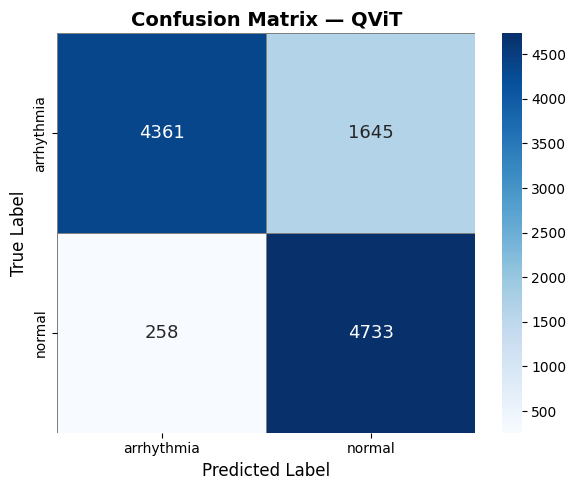

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray', annot_kws={"size": 13})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix — QViT", fontsize=14, fontweight='bold')
plt.savefig("qvit_confusion_matrix.png", dpi=150)
plt.show()

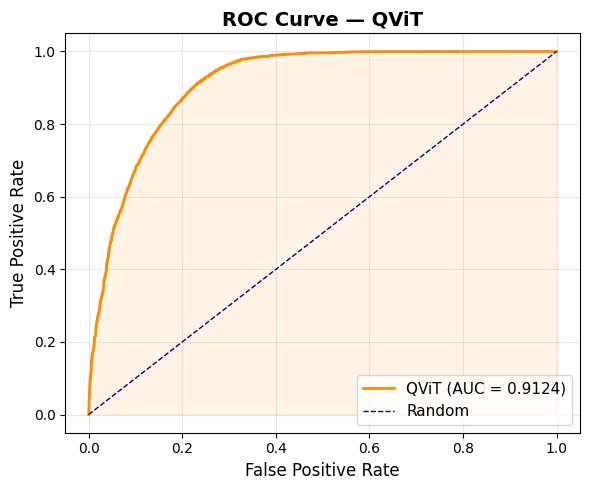

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_true, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f"QViT (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=1,
         linestyle='--', label="Random")
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — QViT", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("qvit_roc_curve.png", dpi=150)
plt.show()

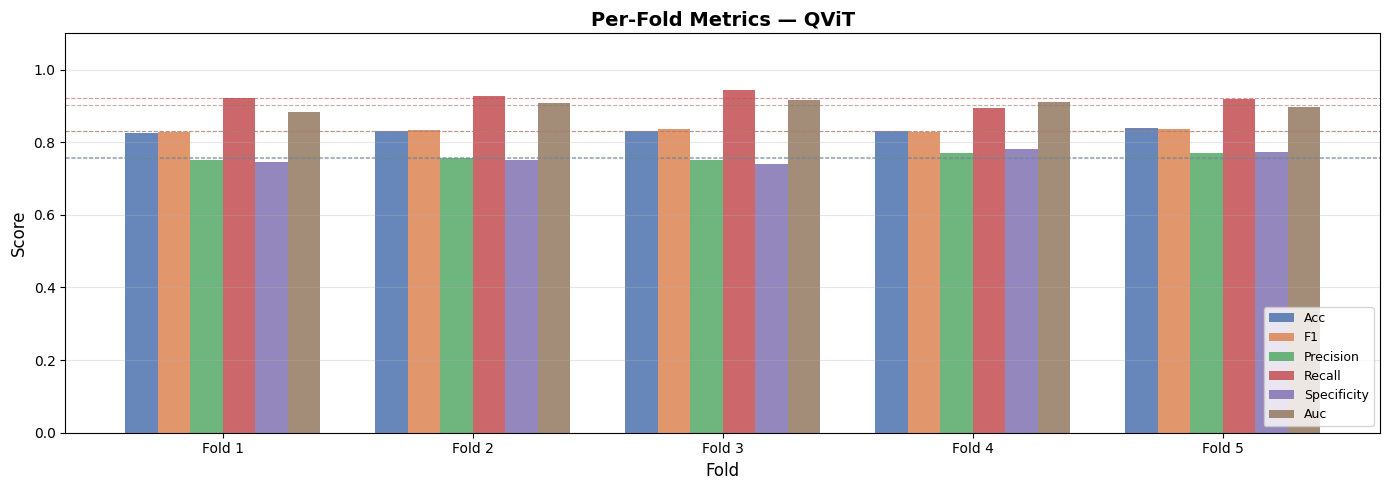

In [36]:
metrics = ["acc", "f1", "precision", "recall", "specificity", "auc"]
colors  = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
x       = np.arange(N_FOLDS)
width   = 0.13

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, df[metric], width,
                  label=metric.capitalize(), color=color, alpha=0.85)

# Mean lines
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.axhline(df[metric].mean(), color=color,
               linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Fold Metrics — QViT", fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([f"Fold {i+1}" for i in range(N_FOLDS)])
ax.set_ylim(0, 1.1)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("qvit_fold_metrics.png", dpi=150)
plt.show()

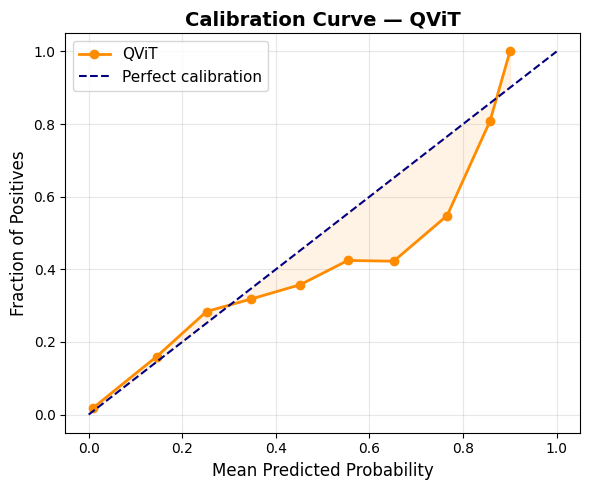

In [37]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(all_true, all_probs, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o',
         color='darkorange', lw=2, label="QViT")
plt.plot([0, 1], [0, 1], '--', color='navy', label="Perfect calibration")
plt.fill_between(prob_pred, prob_true, prob_pred,
                 alpha=0.1, color='darkorange')
plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Fraction of Positives", fontsize=12)
plt.title("Calibration Curve — QViT", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("qvit_calibration.png", dpi=150)
plt.show()


===== FETAL CARDIAC ANALYSIS =====
  Prediction    : ARRHYTHMIA
  Confidence    : 99.43%
  P(arrhythmia) : 0.9943
  P(normal)     : 0.0057


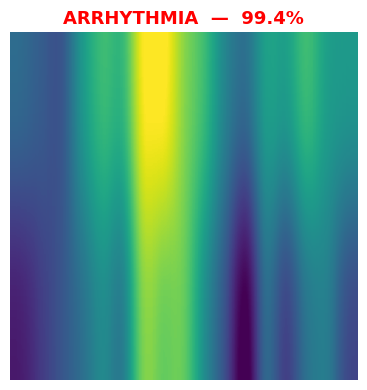


===== FETAL CARDIAC ANALYSIS =====
  Prediction    : NORMAL
  Confidence    : 89.25%
  P(arrhythmia) : 0.1075
  P(normal)     : 0.8925


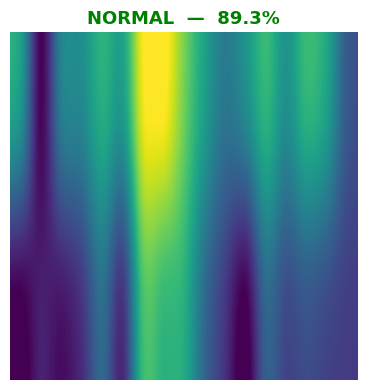

('normal', 0.8925271034240723)

In [38]:
def predict_ecg(img_path):
    model.eval()
    img = Image.open(img_path)
    x   = val_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out   = model(x)
        probs = torch.softmax(out, dim=1)
        conf, pred = torch.max(probs, dim=1)

    label = CLASSES[pred.item()]
    color = "red" if label == "arrhythmia" else "green"

    print("\n===== FETAL CARDIAC ANALYSIS =====")
    print(f"  Prediction    : {label.upper()}")
    print(f"  Confidence    : {conf.item()*100:.2f}%")
    print(f"  P(arrhythmia) : {probs[0][0].item():.4f}")
    print(f"  P(normal)     : {probs[0][1].item():.4f}")

    plt.figure(figsize=(5, 4))
    plt.imshow(img, cmap="viridis")
    plt.title(f"{label.upper()}  —  {conf.item()*100:.1f}%",
              color=color, fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return label, conf.item()

# Test both classes
predict_ecg(r"D:\vit_data\val\arrhythmia\ARR_03_809.png")
predict_ecg(r"D:\vit_data\val\normal\NR_01_125.png")